# Demo Data Inspection

This notebook loads and inspects the outputs of `generate_demo_data.py`.

**Expected files:**
- `data/demo/stops/user_group=00/stops.parquet` — stop-level mobility records
- `data/demo/demographics/demographics.parquet` — user demographic attributes

Run `generate_demo_data.py` first if the files do not exist:
```bash
python data/demo/generate_demo_data.py
```

The results obtained from this demo dataset are not intended to reproduce the findings reported in our analysis; rather, the goal is to demonstrate that the code runs correctly and can be applied to a sample of users.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- Paths (relative to repo root) ----
REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), "../.."))
STOPS_PATH   = os.path.join(REPO_ROOT, "data/demo/stops/user_group=00/stops.parquet")
DEMO_PATH    = os.path.join(REPO_ROOT, "data/demo/demographics/demographics.parquet")

print("Stops path:       ", STOPS_PATH)
print("Demographics path:", DEMO_PATH)
print("Stops exists:     ", os.path.exists(STOPS_PATH))
print("Demo exists:      ", os.path.exists(DEMO_PATH))

Stops path:        /home/sdsc/gender_constrains/p1_gender_entropy/00_gendered-mobility-networks/data/demo/stops/user_group=00/stops.parquet
Demographics path: /home/sdsc/gender_constrains/p1_gender_entropy/00_gendered-mobility-networks/data/demo/demographics/demographics.parquet
Stops exists:      True
Demo exists:       True


---
## 1. Stops dataset

In [17]:
df_stops = pd.read_parquet(STOPS_PATH)
print(f"Shape: {df_stops.shape}")
df_stops.head(10)

Shape: (8580, 7)


,useruuid,loc,start,end,latitude,longitude,timezone
0,00-001,0,1735690246,1735694413,-33.927261,151.357503,36000
1,00-001,0,1735695871,1735703682,-33.927261,151.357503,36000
2,00-001,1,1735704105,1735705058,-34.049376,151.023276,36000
3,00-001,1,1735705580,1735706804,-34.049376,151.023276,36000
4,00-001,0,1735707168,1735710580,-33.927261,151.357503,36000
5,00-001,2,1735711498,1735711913,-33.796954,151.168912,36000
6,00-001,3,1735712399,1735714872,-33.940410,151.019996,36000
7,00-001,1,1735717016,1735730332,-34.049376,151.023276,36000
8,00-001,1,1735737532,1735740268,-34.049376,151.023276,36000
9,00-001,4,1735740764,1735741064,-33.868126,151.142193,36000


In [18]:
# Schema
print("=== Schema ===")
print(df_stops.dtypes)
print("\n=== Null counts ===")
print(df_stops.isnull().sum())

=== Schema ===
useruuid      object
loc            int64
start          int64
end            int64
latitude     float64
longitude    float64
timezone       int64
dtype: object

=== Null counts ===
useruuid     0
loc          0
start        0
end          0
latitude     0
longitude    0
timezone     0
dtype: int64


In [19]:
# Timestamp range (convert unix seconds → datetime)
df_stops["start_dt"] = pd.to_datetime(df_stops["start"], unit="s", utc=True)
df_stops["end_dt"]   = pd.to_datetime(df_stops["end"],   unit="s", utc=True)
print("Start range:", df_stops["start_dt"].min(), "→", df_stops["start_dt"].max())
print("End range:  ", df_stops["end_dt"].min(),   "→", df_stops["end_dt"].max())

Start range: 2025-01-01 00:01:45+00:00 → 2025-01-13 06:07:48+00:00
End range:   2025-01-01 00:06:45+00:00 → 2025-01-13 09:22:03+00:00


In [20]:
# Per-user summary
user_summary = df_stops.groupby("useruuid").agg(
    total_visits   = ("loc", "count"),
    unique_locs    = ("loc", "nunique"),
    duration_hrs   = ("end", lambda x: (x - df_stops.loc[x.index, "start"]).mean() / 3600),
).reset_index()

print(f"Number of users: {len(user_summary)}")
print("\nPer-user statistics:")
user_summary[["total_visits", "unique_locs", "duration_hrs"]].describe().round(2)

Number of users: 100

Per-user statistics:


,total_visits,unique_locs,duration_hrs
count,100.00,100.00,100.00
mean,85.80,30.29,0.79
std,39.98,11.56,0.08
min,25.00,13.00,0.61
25%,58.75,22.00,0.73
50%,76.50,28.00,0.79
75%,99.50,36.00,0.84
max,228.00,66.00,1.03


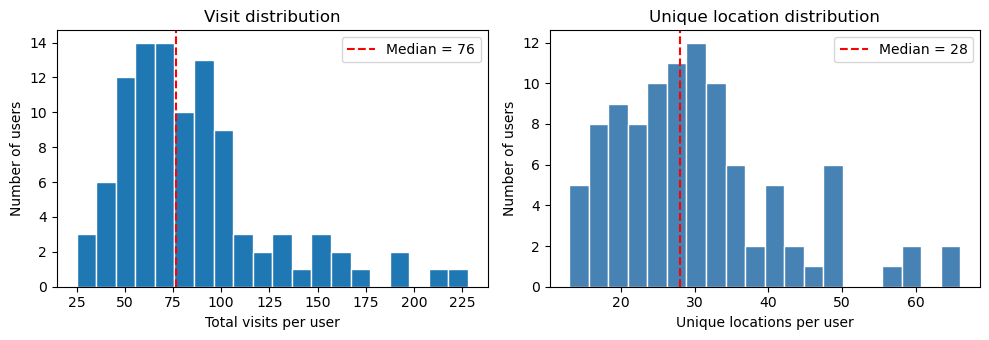

In [21]:
# Distribution of visits and unique locations
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(user_summary["total_visits"], bins=20, edgecolor="white")
axes[0].axvline(user_summary["total_visits"].median(), color="red", linestyle="--", label=f'Median = {user_summary["total_visits"].median():.0f}')
axes[0].set_xlabel("Total visits per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Visit distribution")
axes[0].legend()

axes[1].hist(user_summary["unique_locs"], bins=20, edgecolor="white", color="steelblue")
axes[1].axvline(user_summary["unique_locs"].median(), color="red", linestyle="--", label=f'Median = {user_summary["unique_locs"].median():.0f}')
axes[1].set_xlabel("Unique locations per user")
axes[1].set_ylabel("Number of users")
axes[1].set_title("Unique location distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# Spatial extent of stops
print("Latitude  range:", df_stops["latitude"].min().round(3),  "→", df_stops["latitude"].max().round(3))
print("Longitude range:", df_stops["longitude"].min().round(3), "→", df_stops["longitude"].max().round(3))
print("Unique timezone offsets (seconds):", sorted(df_stops["timezone"].unique()))

Latitude  range: -34.234 → 59.777
Longitude range: -74.572 → 151.809
Unique timezone offsets (seconds): [-18000, 0, 3600, 28800, 32400, 36000]


---
## 2. Demographics dataset

In [23]:
df_demo = pd.read_parquet(DEMO_PATH)
print(f"Shape: {df_demo.shape}")
df_demo.head(10)

Shape: (100, 4)


,useruuid,gender,GID_0,NAME_0
0,00-001,MALE,AUS,Australia
1,00-002,MALE,GBR,United Kingdom
2,00-003,MALE,DEU,Germany
3,00-004,FEMALE,JPN,Japan
4,00-005,MALE,NLD,Netherlands
5,00-006,FEMALE,ESP,Spain
6,00-007,MALE,SWE,Sweden
7,00-008,FEMALE,ESP,Spain
8,00-009,MALE,GBR,United Kingdom
9,00-010,FEMALE,DEU,Germany


In [24]:
# Schema
print("=== Schema ===")
print(df_demo.dtypes)
print("\n=== Null counts ===")
print(df_demo.isnull().sum())

=== Schema ===
useruuid    object
gender      object
GID_0       object
NAME_0      object
dtype: object

=== Null counts ===
useruuid    0
gender      0
GID_0       0
NAME_0      0
dtype: int64


In [25]:
# Gender distribution
print("Gender distribution:")
print(df_demo["gender"].value_counts())
print("\nCountry distribution:")
print(df_demo[["GID_0", "NAME_0"]].value_counts().to_string())

Gender distribution:
gender
MALE      56
FEMALE    44
Name: count, dtype: int64

Country distribution:
GID_0  NAME_0        
DEU    Germany           18
GBR    United Kingdom    15
TWN    Taiwan            11
SWE    Sweden            11
AUS    Australia          8
ESP    Spain              8
USA    United States      8
JPN    Japan              8
NLD    Netherlands        7
FRA    France             6


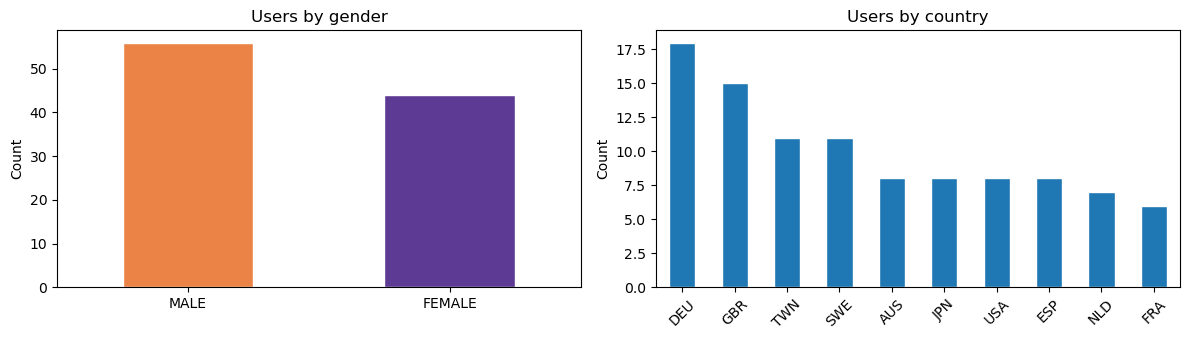

In [26]:
# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

df_demo["gender"].value_counts().plot(kind="bar", ax=axes[0], color=["#EB8347", "#5D3A93"], edgecolor="white")
axes[0].set_title("Users by gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df_demo["GID_0"].value_counts().plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("Users by country")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Join stops + demographics

In [27]:
df_merged = df_stops.merge(df_demo, on="useruuid", how="left")

print(f"Stops with matched demographics: {df_merged['gender'].notna().sum()} / {len(df_merged)}")
print(f"Unmatched stops: {df_merged['gender'].isna().sum()}")
df_merged.head(5)

Stops with matched demographics: 8580 / 8580
Unmatched stops: 0


,useruuid,loc,start,end,latitude,longitude,timezone,start_dt,end_dt,gender,GID_0,NAME_0
0,00-001,0,1735690246,1735694413,-33.927261,151.357503,36000,2025-01-01 00:10:46+00:00,2025-01-01 01:20:13+00:00,MALE,AUS,Australia
1,00-001,0,1735695871,1735703682,-33.927261,151.357503,36000,2025-01-01 01:44:31+00:00,2025-01-01 03:54:42+00:00,MALE,AUS,Australia
2,00-001,1,1735704105,1735705058,-34.049376,151.023276,36000,2025-01-01 04:01:45+00:00,2025-01-01 04:17:38+00:00,MALE,AUS,Australia
3,00-001,1,1735705580,1735706804,-34.049376,151.023276,36000,2025-01-01 04:26:20+00:00,2025-01-01 04:46:44+00:00,MALE,AUS,Australia
4,00-001,0,1735707168,1735710580,-33.927261,151.357503,36000,2025-01-01 04:52:48+00:00,2025-01-01 05:49:40+00:00,MALE,AUS,Australia


In [28]:
# Per-user summary by gender
user_summary_gender = df_merged.groupby(["useruuid", "gender"]).agg(
    total_visits = ("loc", "count"),
    unique_locs  = ("loc", "nunique"),
).reset_index()

print("Per-user stats by gender:")
user_summary_gender.groupby("gender")[["total_visits", "unique_locs"]].median().round(2)

Per-user stats by gender:


,total_visits,unique_locs
gender,,
FEMALE,84.0,27.5
MALE,70.5,28.5


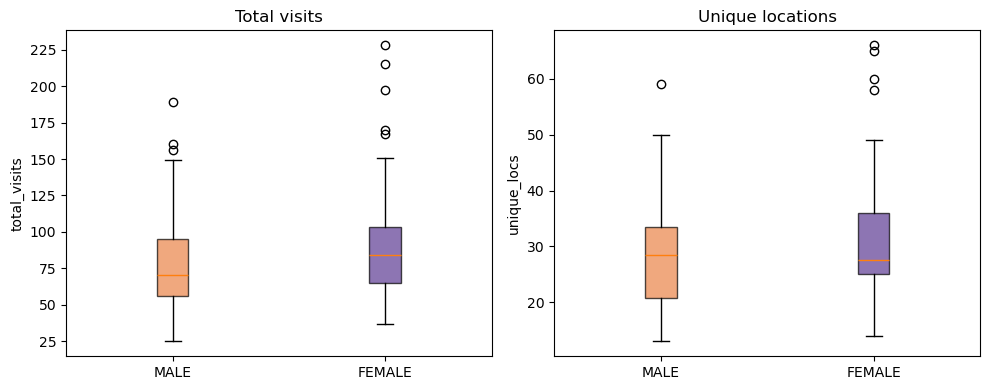

In [29]:
# Boxplot: visits and unique locations by gender
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = {"MALE": "#EB8347", "FEMALE": "#5D3A93"}

for ax, col, title in zip(axes, ["total_visits", "unique_locs"], ["Total visits", "Unique locations"]):
    groups = [user_summary_gender.loc[user_summary_gender["gender"]==g, col].values for g in ["MALE", "FEMALE"]]
    bp = ax.boxplot(groups, labels=["MALE", "FEMALE"], patch_artist=True)
    for patch, g in zip(bp["boxes"], ["MALE", "FEMALE"]):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

---
## 4. Pipeline compatibility check

Verify that all columns required by `01_compute_metrics.py` are present and correctly typed.

In [30]:
REQUIRED_STOPS_COLS = {
    "useruuid":  "object",
    "loc":       "int64",
    "start":     "int64",
    "end":       "int64",
    "latitude":  "float64",
    "longitude": "float64",
    "timezone":  "int64",
}

REQUIRED_DEMO_COLS = {
    "useruuid": "object",
    "gender":   "object",
    "GID_0":    "object",
    "NAME_0":   "object",
}

print("=== Stops schema check ===")
for col, expected_dtype in REQUIRED_STOPS_COLS.items():
    present = col in df_stops.columns
    actual  = str(df_stops[col].dtype) if present else "MISSING"
    status  = "OK" if present and actual == expected_dtype else "MISMATCH" if present else "MISSING"
    print(f"  {col:<12}  expected={expected_dtype:<10}  actual={actual:<10}  [{status}]")

print("\n=== Demographics schema check ===")
for col, expected_dtype in REQUIRED_DEMO_COLS.items():
    present = col in df_demo.columns
    actual  = str(df_demo[col].dtype) if present else "MISSING"
    status  = "OK" if present and actual == expected_dtype else "MISMATCH" if present else "MISSING"
    print(f"  {col:<12}  expected={expected_dtype:<10}  actual={actual:<10}  [{status}]")

print("\n=== Gender values ===")
print("  Valid:  ", sorted(df_demo["gender"].unique()))
print("  Expected: ['FEMALE', 'MALE']")

print("\n=== Country codes ===")
EXPECTED_COUNTRIES = {"AUS", "DEU", "ESP", "FRA", "GBR", "JPN", "NLD", "SWE", "TWN", "USA"}
found = set(df_demo["GID_0"].unique())
print("  Found:   ", sorted(found))
print("  Expected:", sorted(EXPECTED_COUNTRIES))
print("  Missing: ", sorted(EXPECTED_COUNTRIES - found) or "None")

=== Stops schema check ===
  useruuid      expected=object      actual=object      [OK]
  loc           expected=int64       actual=int64       [OK]
  start         expected=int64       actual=int64       [OK]
  end           expected=int64       actual=int64       [OK]
  latitude      expected=float64     actual=float64     [OK]
  longitude     expected=float64     actual=float64     [OK]
  timezone      expected=int64       actual=int64       [OK]

=== Demographics schema check ===
  useruuid      expected=object      actual=object      [OK]
  gender        expected=object      actual=object      [OK]
  GID_0         expected=object      actual=object      [OK]
  NAME_0        expected=object      actual=object      [OK]

=== Gender values ===
  Valid:   ['FEMALE', 'MALE']
  Expected: ['FEMALE', 'MALE']

=== Country codes ===
  Found:    ['AUS', 'DEU', 'ESP', 'FRA', 'GBR', 'JPN', 'NLD', 'SWE', 'TWN', 'USA']
  Expected: ['AUS', 'DEU', 'ESP', 'FRA', 'GBR', 'JPN', 'NLD', 'SWE', 'TWN', '

---
## 5. Pipeline output: `user_metrics_demo.csv`

Output of `01_compute_metrics.py` run on the demo data.  
Expected at `data/demo/output/user_metrics_demo.csv`.

Columns produced:
- **Base:** `useruuid`, `gender`, `GID_0`, `start_month`
- **Mobility metrics:** `visits`, `locations`, `total_stay_time`, `total_travel_time`, `total_cost_travel_distance`, `total_reward_home_distance`, `tour_efficiency_dist`
- **Mobility aux:** `has_home`, `coverage_stay_time`, `sum_home_distance`, `max_home_distance`, `max_reward_home_distance`
- **Network metrics:** `nodes`, `edges`, `density`, `avg_unw_cluster`, `n_cycles`, `top1_degree_centrality`, `global_efficiency_edges`
- **Network aux:** `top2_degree_centrality`, `top3_degree_centrality`, `avg_len_cycles_all`, `n_cycles_per_edge`
- **Efficiency metrics:** `nwide_MFPT_lovasz`, `home_GMFPT_lovasz`, `global_efficiency_distance`
- **Derived:** `activity_deciles`, `repertoire_deciles`, `activity_repertoire_groups`

In [31]:
METRICS_PATH = os.path.join(REPO_ROOT, "data/demo/output/user_metrics_demo.csv")
print("Metrics path:", METRICS_PATH)
print("Exists:      ", os.path.exists(METRICS_PATH))

df = pd.read_csv(METRICS_PATH)
print(f"\nShape: {df.shape}")
df.head(5)

Metrics path: /home/sdsc/gender_constrains/p1_gender_entropy/00_gendered-mobility-networks/data/demo/output/user_metrics_demo.csv
Exists:       True

Shape: (107, 34)


,useruuid,gender,GID_0,start_month,visits,locations,total_stay_time,total_travel_time,total_cost_travel_distance,total_reward_home_distance,...,top2_degree_centrality,top3_degree_centrality,global_efficiency_edges,nwide_MFPT_lovasz,home_GMFPT_lovasz,global_efficiency_distance,user_group,activity_deciles,repertoire_deciles,activity_repertoire_groups
0,00-001,MALE,AUS,1735689600,52,20,158083,74091,1088.57389,NaN,...,0.473684,0.315789,0.475702,58.705209,NaN,0.477786,user_group=00,3,3,inactive
1,00-002,MALE,GBR,1735689600,71,29,206155,103370,1727.11812,NaN,...,0.285714,0.285714,0.478243,57.709140,NaN,0.486091,user_group=00,5,6,moderate
2,00-003,MALE,DEU,1735689600,64,22,179659,87369,1603.02646,NaN,...,0.380952,0.380952,0.542569,40.376778,NaN,0.543452,user_group=00,4,3,other
3,00-004,FEMALE,JPN,1735689600,88,36,268198,124375,2629.36351,NaN,...,0.314286,0.257143,0.427910,85.707942,NaN,0.425187,user_group=00,7,8,other
4,00-005,MALE,NLD,1735689600,144,50,389931,177145,3969.76250,NaN,...,0.326531,0.285714,0.443129,117.671988,NaN,0.448387,user_group=00,10,10,active


In [32]:
# Column groups
MOBILITY_METRICS  = ["visits", "locations", "total_stay_time", "total_travel_time",
                     "total_cost_travel_distance", "total_reward_home_distance", "tour_efficiency_dist"]
MOBILITY_AUX      = ["has_home", "coverage_stay_time", "sum_home_distance",
                     "max_home_distance", "max_reward_home_distance"]
NETWORK_METRICS   = ["nodes", "edges", "density", "avg_unw_cluster",
                     "n_cycles", "top1_degree_centrality", "global_efficiency_edges"]
NETWORK_AUX       = ["top2_degree_centrality", "top3_degree_centrality",
                     "avg_len_cycles_all", "n_cycles_per_edge"]
EFFICIENCY_METRICS = ["nwide_MFPT_lovasz", "home_GMFPT_lovasz", "global_efficiency_distance"]

ALL_METRICS = MOBILITY_METRICS + MOBILITY_AUX + NETWORK_METRICS + NETWORK_AUX + EFFICIENCY_METRICS

# Filter to columns that actually exist (pipeline may skip some if data is thin)
present = [c for c in ALL_METRICS if c in df.columns]
missing = [c for c in ALL_METRICS if c not in df.columns]
print(f"Metric columns present: {len(present)} / {len(ALL_METRICS)}")
if missing:
    print(f"Missing (not produced by pipeline): {missing}")

Metric columns present: 26 / 26


In [33]:
# Full descriptive statistics across all metrics
df[present].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
visits,107.0,80.159,43.438,4.000,53.000,74.000,98.500,228.000
locations,107.0,28.514,13.036,3.000,20.000,27.000,34.500,66.000
total_stay_time,107.0,230844.234,135115.149,6060.000,147019.000,207065.000,281523.000,700144.000
total_travel_time,107.0,118454.206,68468.437,2901.000,74799.000,106421.000,149855.000,367437.000
total_cost_travel_distance,107.0,2018.523,1204.660,47.538,1271.265,1867.324,2507.310,7663.279
total_reward_home_distance,1.0,1334.513,NaN,1334.513,1334.513,1334.513,1334.513,1334.513
tour_efficiency_dist,1.0,0.052,NaN,0.052,0.052,0.052,0.052,0.052
has_home,107.0,0.009,0.097,0.000,0.000,0.000,0.000,1.000
coverage_stay_time,107.0,0.086,0.050,0.002,0.055,0.077,0.105,0.261
sum_home_distance,1.0,667.256,NaN,667.256,667.256,667.256,667.256,667.256


In [34]:
# Null / coverage check
null_pct = (df[present].isnull().sum() / len(df) * 100).round(1).rename("null_%")
print("Null % per metric column:")
print(null_pct[null_pct > 0].to_string() if null_pct.any() else "  No nulls found.")

Null % per metric column:
total_reward_home_distance    99.1
tour_efficiency_dist          99.1
sum_home_distance             99.1
max_home_distance             99.1
max_reward_home_distance      99.1
home_GMFPT_lovasz             99.1


### 5.1 Mobility metrics distributions

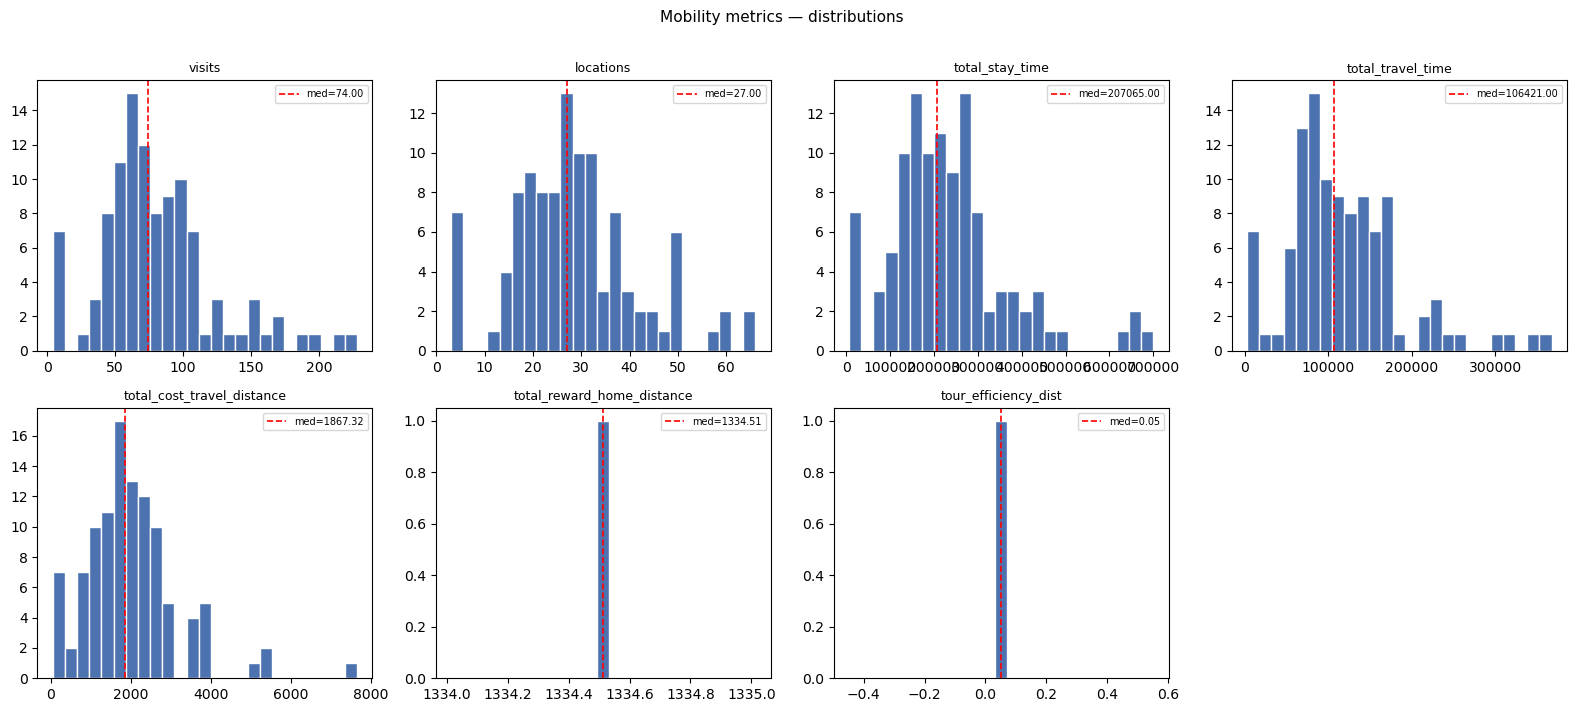

In [35]:
mob_present = [c for c in MOBILITY_METRICS if c in df.columns]
n = len(mob_present)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(mob_present):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor="white", color="#4C72B0")
    axes[i].axvline(df[col].median(), color="red", linestyle="--", linewidth=1.2,
                    label=f"med={df[col].median():.2f}")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Mobility metrics — distributions", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Network metrics distributions

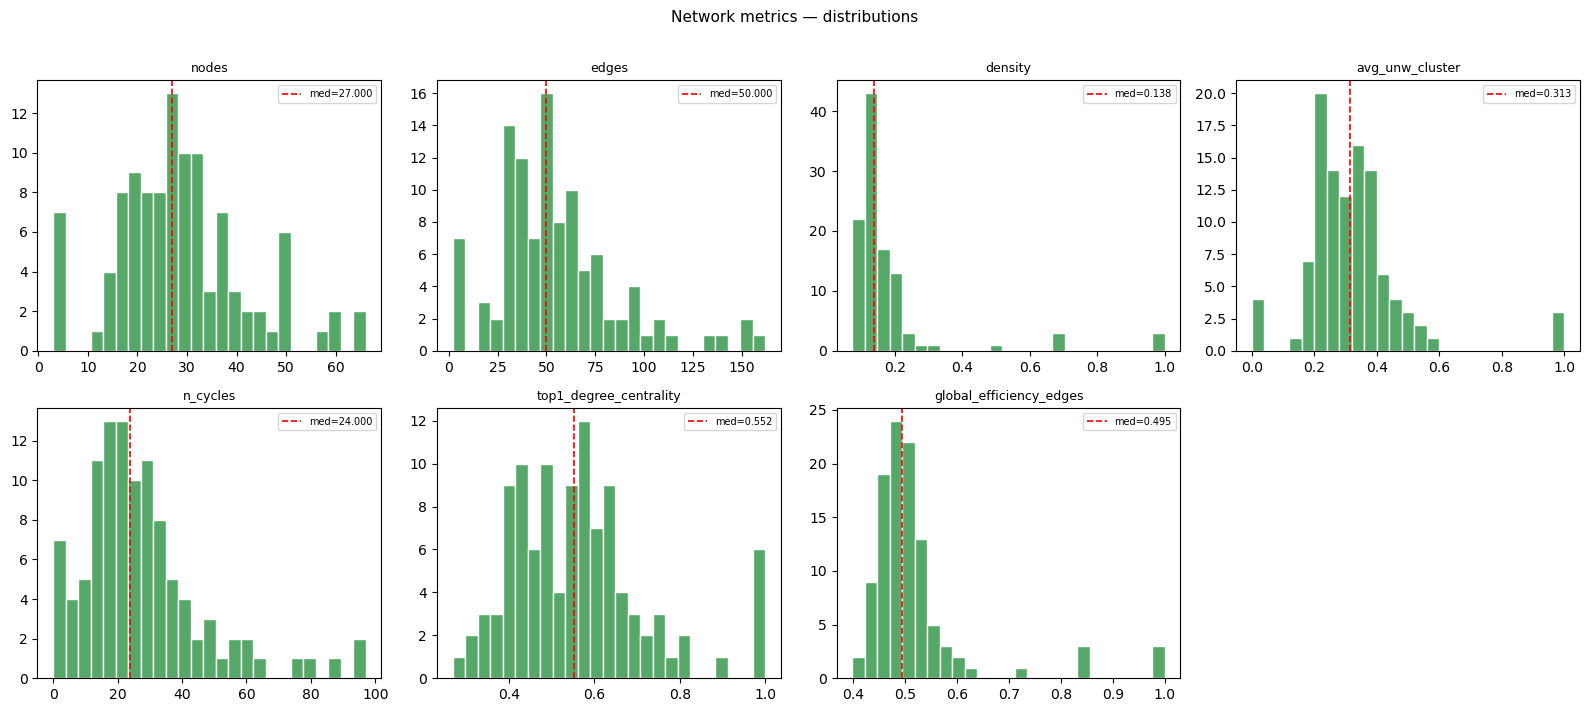

In [36]:
net_present = [c for c in NETWORK_METRICS if c in df.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(net_present):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor="white", color="#55A868")
    axes[i].axvline(df[col].median(), color="red", linestyle="--", linewidth=1.2,
                    label=f"med={df[col].median():.3f}")
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Network metrics — distributions", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Efficiency metrics distributions

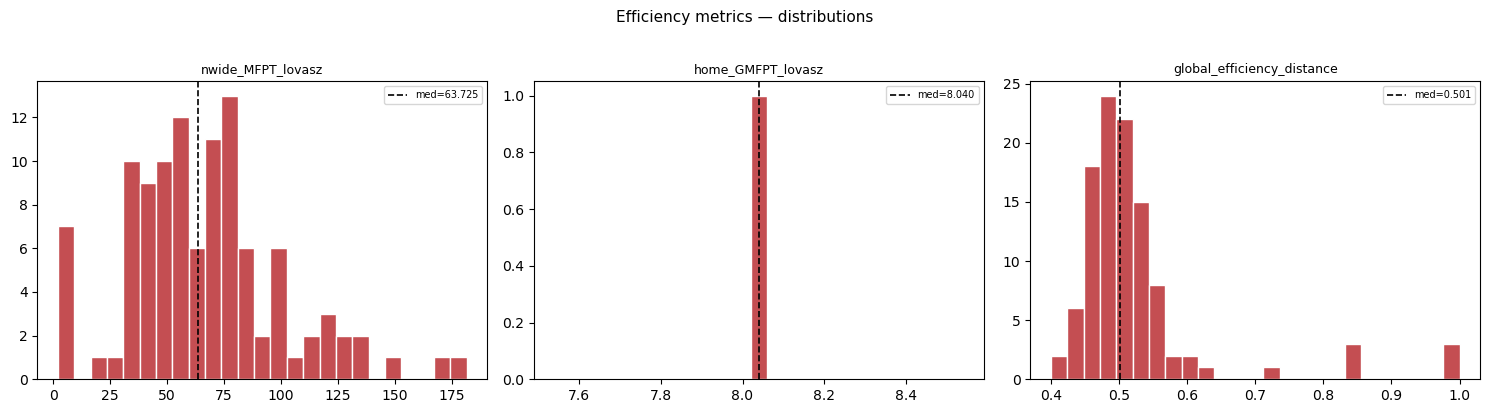

In [37]:
eff_present = [c for c in EFFICIENCY_METRICS if c in df.columns]
fig, axes = plt.subplots(1, len(eff_present), figsize=(5 * len(eff_present), 4))
if len(eff_present) == 1:
    axes = [axes]

for ax, col in zip(axes, eff_present):
    ax.hist(df[col].dropna(), bins=25, edgecolor="white", color="#C44E52")
    ax.axvline(df[col].median(), color="black", linestyle="--", linewidth=1.2,
               label=f"med={df[col].median():.3f}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Efficiency metrics — distributions", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Gender comparison — key metrics

/home/sdsc/.conda/envs/gender_eff/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sdsc/.conda/envs/gender_eff/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values


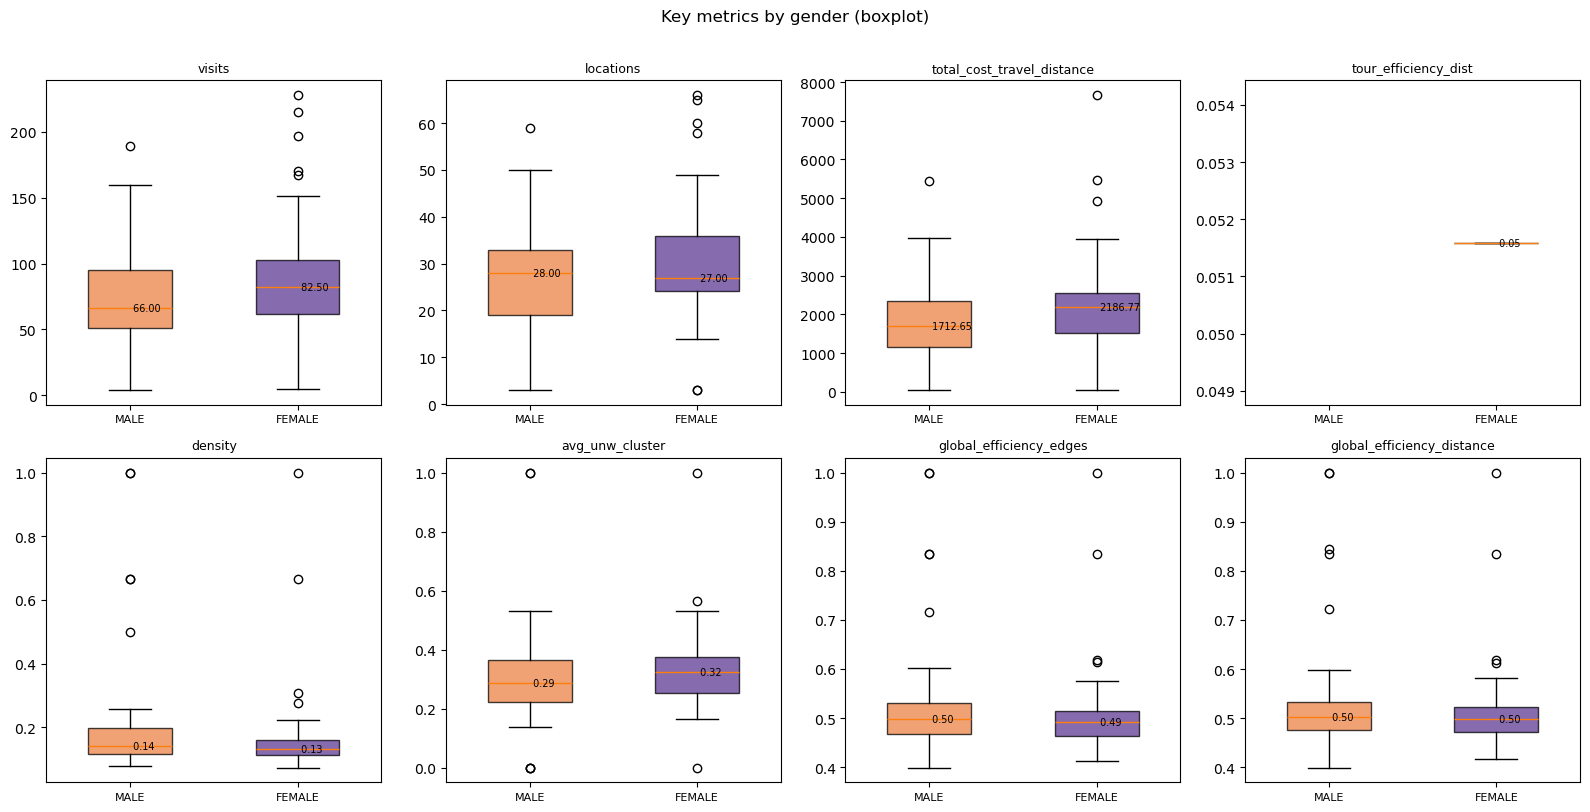


Median by gender:


,visits,locations,total_cost_travel_distance,tour_efficiency_dist,density,avg_unw_cluster,global_efficiency_edges,global_efficiency_distance
gender,,,,,,,,
FEMALE,82.5,27.0,2186.770,0.052,0.132,0.323,0.491,0.498
MALE,66.0,28.0,1712.647,NaN,0.140,0.287,0.499,0.502


In [38]:
KEY_METRICS = [c for c in ["visits", "locations", "total_cost_travel_distance",
                            "tour_efficiency_dist", "density", "avg_unw_cluster",
                            "global_efficiency_edges", "global_efficiency_distance"]
               if c in df.columns]

COLORS = {"MALE": "#EB8347", "FEMALE": "#5D3A93"}
genders = ["MALE", "FEMALE"]

n_cols = 4
n_rows = int(np.ceil(len(KEY_METRICS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(KEY_METRICS):
    groups = [df.loc[df["gender"] == g, col].dropna().values for g in genders]
    bp = axes[i].boxplot(groups, labels=genders, patch_artist=True, widths=0.5)
    for patch, g in zip(bp["boxes"], genders):
        patch.set_facecolor(COLORS[g])
        patch.set_alpha(0.75)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", labelsize=8)

    # Annotate medians
    for j, g in enumerate(genders):
        med = np.median(df.loc[df["gender"] == g, col].dropna())
        axes[i].text(j + 1, med, f" {med:.2f}", va="center", fontsize=7, color="black")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key metrics by gender (boxplot)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Median table
print("\nMedian by gender:")
df.groupby("gender")[KEY_METRICS].median().round(3)

### 5.5 Activity-repertoire groups

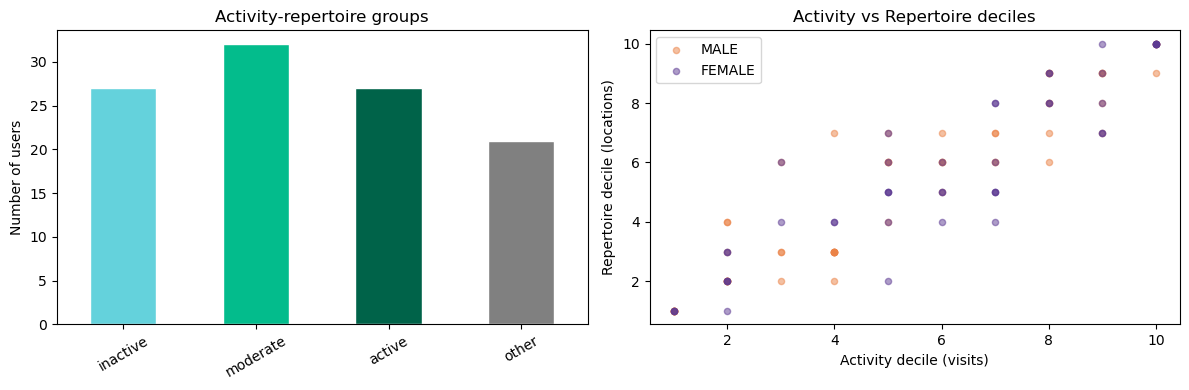

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Activity-repertoire group counts
if "activity_repertoire_groups" in df.columns:
    group_order = ["inactive", "moderate", "active", "other"]
    group_colors = {"inactive": "#64D2DC", "moderate": "#03BC8C", "active": "#006349", "other": "grey"}
    counts = df["activity_repertoire_groups"].value_counts().reindex(group_order).dropna()
    counts.plot(kind="bar", ax=axes[0],
                color=[group_colors.get(g, "grey") for g in counts.index],
                edgecolor="white")
    axes[0].set_title("Activity-repertoire groups")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("Number of users")
else:
    axes[0].text(0.5, 0.5, "activity_repertoire_groups\nnot found", ha="center", va="center")
    axes[0].axis("off")

# Scatter: activity decile vs repertoire decile
if "activity_deciles" in df.columns and "repertoire_deciles" in df.columns:
    for g, c in COLORS.items():
        sub = df[df["gender"] == g]
        axes[1].scatter(sub["activity_deciles"], sub["repertoire_deciles"],
                        alpha=0.5, s=20, color=c, label=g)
    axes[1].set_xlabel("Activity decile (visits)")
    axes[1].set_ylabel("Repertoire decile (locations)")
    axes[1].set_title("Activity vs Repertoire deciles")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Decile columns not found", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()